In [2]:
import sys
import argparse

sys.argv = ['script_name', '--forward_amount', '0.5']

parser = argparse.ArgumentParser()
parser.add_argument('--forward_amount', type=float, help='前进的距离')

args = parser.parse_args()
from config import config
from env.v0d0 import Env
import torch
import numpy as np
import habitat_sim
from habitat.utils.visualizations import maps
import random
from draw import Draw
drawer  = Draw()

/home/getuanhui/anaconda3/envs/ss/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-02-19 11:09:19.844608: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-19 11:09:19.862870: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-19 11:09:19.862888: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-19 11:09

In [3]:
config['random_seed'] = 1
env = Env(config)
sim = env._sim
env.reset()

[11:09:21:240996]:[Metadata] SceneDatasetAttributesManager.cpp(308)::readDatasetJSONCell : "stages.default_attributes" set in Attributes Manager from JSON.
[11:09:21:241026]:[Metadata] AttributesManagerBase.h(352)::buildAttrSrcPathsFromJSONAndLoad : Glob path result for ../data/scene_datasets/mp3d/*/*.glb : ../data/scene_datasets/mp3d/17DRP5sb8fy/17DRP5sb8fy.glb
[11:09:21:241071]:[Metadata] SceneInstanceAttributesManager.cpp(65)::setValsFromJSONDoc : No Stage specified for scene default_attributes , or specification error.
[11:09:21:241074]:[Metadata] SceneInstanceAttributesManager.cpp(105)::setValsFromJSONDoc : No Articulated Objects specified for scene default_attributes , or specification error.
[11:09:21:241077]:[Metadata] SceneInstanceAttributesManager.cpp(125)::setValsFromJSONDoc : No navmesh_instance specified for scene default_attributes .
[11:09:21:241080]:[Metadata] SceneInstanceAttributesManager.cpp(135)::setValsFromJSONDoc : No semantic_scene_instance specified for scene de

source_poses [array([3.2412243 , 0.072447  , 0.56138235], dtype=float32)][11:09:21:240531]:[Metadata] AttributesManagerBase.h(380)::createFromJsonOrDefaultInternal : <Dataset>: Proposing JSON name : default.scene_dataset_config.json from original name : default| This file does not exist.
[11:09:21:240575]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (capsule3DSolid:capsule3DSolid_hemiRings_4_cylRings_1_segments_12_halfLen_0.75_useTexCoords_false_useTangents_false) created and registered.
[11:09:21:240589]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (capsule3DWireframe:capsule3DWireframe_hemiRings_8_cylRings_1_segments_16_halfLen_1) created and registered.
[11:09:21:240597]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (coneSolid:coneSolid_segments_12_halfLen_1.25_rings_1_useTexCoords_false_useTangents_false_capEnd_true) created and registered.
[11:09:21:240605]:[Metadata] AssetAttributesManager

Material for category 'picture' was not found. Using default material instead.
Material for category 'objects' was not found. Using default material instead.
Material for category 'void' was not found. Using default material instead.
Material for category 'misc' was not found. Using default material instead.


[{'camera': array([[[146, 139, 115, 255],
          [146, 139, 116, 255],
          [147, 140, 117, 255],
          ...,
          [130, 123, 101, 255],
          [130, 123, 101, 255],
          [129, 122,  99, 255]],
  
         [[146, 139, 116, 255],
          [148, 140, 119, 255],
          [149, 141, 120, 255],
          ...,
          [129, 122, 100, 255],
          [129, 122, 100, 255],
          [127, 120,  97, 255]],
  
         [[146, 141, 121, 255],
          [149, 143, 124, 255],
          [150, 142, 121, 255],
          ...,
          [127, 121, 100, 255],
          [126, 119,  99, 255],
          [125, 118,  99, 255]],
  
         ...,
  
         [[184, 176, 159, 255],
          [191, 180, 160, 255],
          [194, 187, 169, 255],
          ...,
          [156, 142, 123, 255],
          [154, 141, 122, 255],
          [152, 139, 120, 255]],
  
         [[184, 176, 159, 255],
          [190, 180, 158, 255],
          [195, 186, 168, 255],
          ...,
          [155, 14

In [4]:
print(f"agent pos {env.get_agent_pos()} \nsound pos {env.get_source_pos()}")

agent pos [array([1.4503706 , 0.072447  , 0.15110967], dtype=float32)] 
sound pos [array([3.2412243 , 0.072447  , 0.56138235], dtype=float32)]


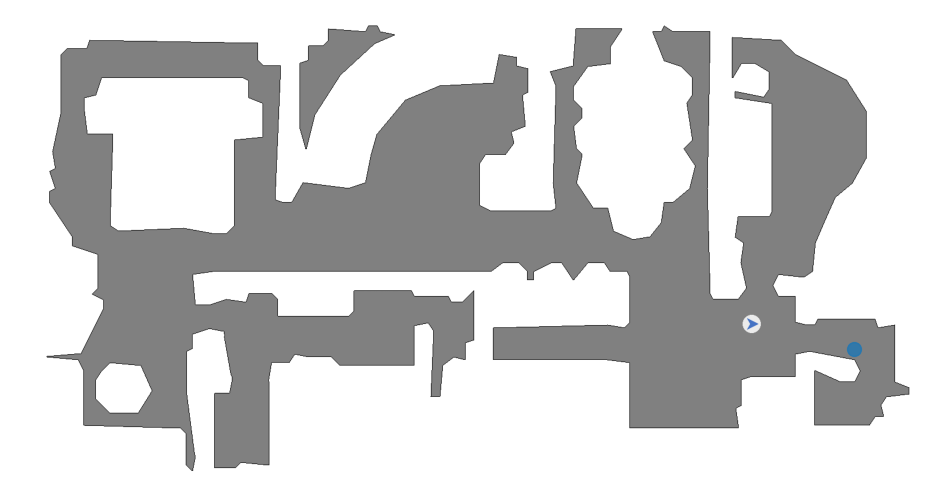

In [5]:
drawer.show_graph(env)

In [6]:
env.get_shortest_action_list()

SystemError: <built-in method __next__ of PyCapsule object at 0x7f4f9b1624b0> returned NULL without setting an error

In [8]:
import sys
import argparse

sys.argv = ['script_name', '--forward_amount', '0.5']

parser = argparse.ArgumentParser()
parser.add_argument('--forward_amount', type=float, help='前进的距离')
import logging
import torch
import os
import time
import random
import ray
import habitat_sim
import pickle
from config import config
from env.v0d0 import Env
from utils.batch import *
random.seed(config["random_seed"])

2025-02-19 11:12:04,170	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [53]:
import pickle
import os 
path = './data/RL/random'
files = os.listdir(path)[88]
file = os.path.join(path,files)

In [54]:
file

'./data/RL/random/offline_episode_RL_363.pkl'

In [55]:
with open(file ,'rb') as f:
    data = pickle.load(f)

In [56]:
data[0]['reward']

array([  0.       ,   0.       ,   0.       ,   2.4279213,   0.       ,
         2.3811054,   0.       ,   2.440176 ,   0.       ,   2.501545 ,
         2.4971676,   2.4964619,   2.495451 ,   2.4939609,   2.4915648,
         2.4874115,   2.479539 ,   2.4720597,   2.464056 ,   2.4520802,
         2.429285 ,   2.3933744,   0.       ,   2.4393964,   0.       ,
         2.386961 ,   0.       ,   2.4419749,   0.       , 102.150536 ,
       100.       , 100.       , 102.49637  , 100.       , 101.84294  ,
       100.       , 100.       ,  98.67254  , 100.       ,  98.6714   ,
        98.1384   ,  -2.122497 ,   0.       ,   0.       ,  -2.1916795,
        -2.2866333,  -2.3446715,  -2.3823166,  -2.4079633,  -2.4261522,
        -2.4394917,  -2.4495459,  -2.457304 ,  -2.46341  ,  -2.4683046,
        -2.4722838,  -2.4755573,   0.       ,  -2.002616 ,  -2.051196 ,
         0.       ], dtype=float32)